<a href="https://colab.research.google.com/github/YashitaaArya/Python-Practices/blob/main/EcodingNumericalFeatures.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [2]:
df=pd.read_csv("train.csv", usecols=['Age', 'Fare', 'Survived'])

In [3]:
df.dropna(inplace=True)

In [4]:
df.shape

(714, 3)

In [5]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [6]:
# first let's check without any sort of binning, what is our result
x=df.iloc[:, 1:]
y=df.iloc[:, 0]

In [7]:
x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=0.2, random_state=42)

In [8]:
x_train.head(2)

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542


In [9]:
clf=DecisionTreeClassifier()
clf.fit(x_train, y_train)
y_pred=clf.predict(x_test)
accuracy_score(y_test, y_pred)

0.6153846153846154

In [10]:
np.mean(cross_val_score(DecisionTreeClassifier(), x, y, cv=10, scoring='accuracy'))

np.float64(0.6261345852895148)

In [20]:
# on applying discretizer
kbin_age=KBinsDiscretizer(n_bins=15, encode='ordinal', strategy='quantile')
kbin_fare=KBinsDiscretizer(n_bins=15, encode='ordinal', strategy='quantile')

In [21]:
trf=ColumnTransformer([
    ('first', kbin_age, [0]),
    ('second', kbin_fare, [1])
])

In [22]:
x_train_trf=trf.fit_transform(x_train)
x_test_trf=trf.transform(x_test)
#

In [23]:
trf.named_transformers_

{'first': KBinsDiscretizer(encode='ordinal', n_bins=15),
 'second': KBinsDiscretizer(encode='ordinal', n_bins=15)}

In [24]:
trf.named_transformers_['first'].n_bins_

array([15])

In [25]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42,  6.  , 16.  , 19.  , 21.  , 23.  , 25.  , 28.  , 30.  ,
              32.  , 35.  , 38.  , 42.  , 47.  , 54.  , 80.  ])             ],
      dtype=object)

In [26]:
output=pd.DataFrame({
    'age':x_train['Age'],
    'age_trf':x_train_trf[:, 0],
    'fare':x_train['Fare'],
    'fare_trf':x_train_trf[:, 1]
})

In [27]:
output['age_labels']=pd.cut(x=x_train['Age'], bins=trf.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_labels']=pd.cut(x=x_train['Fare'], bins=trf.named_transformers_['second'].bin_edges_[0].tolist())

In [28]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
676,24.5,5.0,8.0500,3.0,"(23.0, 25.0]","(7.896, 8.158]"
614,35.0,10.0,8.0500,3.0,"(32.0, 35.0]","(7.896, 8.158]"
528,39.0,11.0,7.9250,3.0,"(38.0, 42.0]","(7.896, 8.158]"
62,45.0,12.0,83.4750,13.0,"(42.0, 47.0]","(76.292, 108.9]"
521,22.0,4.0,7.8958,3.0,"(21.0, 23.0]","(7.775, 7.896]"


In [29]:
clf=DecisionTreeClassifier()
clf.fit(x_train_trf, y_train)
y_pred2=clf.predict(x_test_trf)
accuracy_score(y_test, y_pred2)
#

0.6363636363636364

In [30]:
x_trf=trf.fit_transform(x)
np.mean(cross_val_score(DecisionTreeClassifier(), x_trf, y, cv=10, scoring='accuracy'))
#

np.float64(0.6723004694835681)

In [33]:
def discretize(bins, strategy):
    kbin_age=KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy=strategy)
    kbin_fare=KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy=strategy)
    trf=ColumnTransformer([
        ('first', kbin_age, [0]),
        ('second', kbin_fare, [1])
    ])
    x_trf=trf.fit_transform(x)
    print(np.mean(cross_val_score(DecisionTreeClassifier(), x, y, cv=10, scoring='accuracy')))

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(x['Age'])
    plt.title('Before')

    plt.subplot(122)
    plt.hist(x_trf[:,0], color='red')
    plt.title('After')
    plt.show()

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(x['Fare'])
    plt.title('Before')

    plt.subplot(122)
    plt.hist(x_trf[:,1], color='red')
    plt.title('After')
    plt.show()

0.6289319248826291


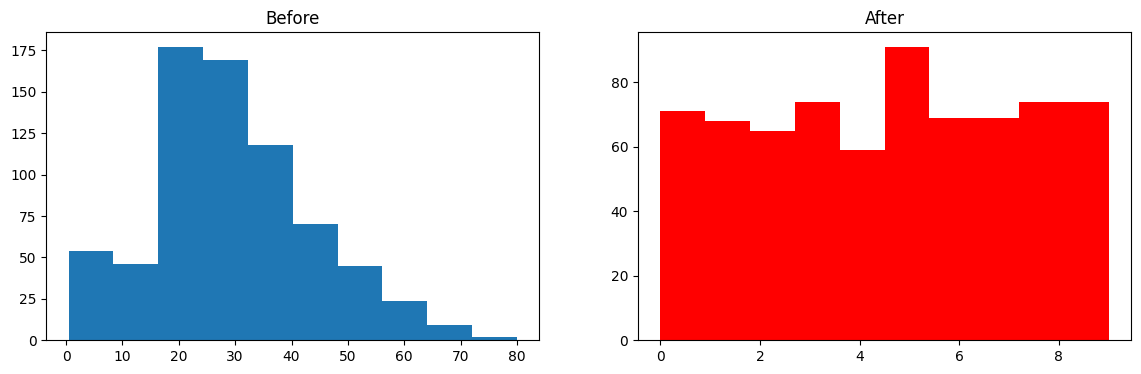

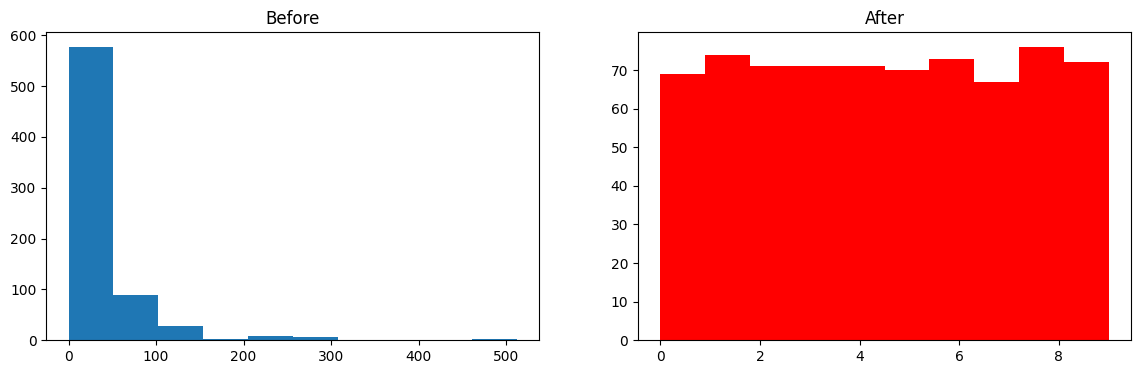

In [34]:
discretize(10, 'quantile')

0.6317292644757433


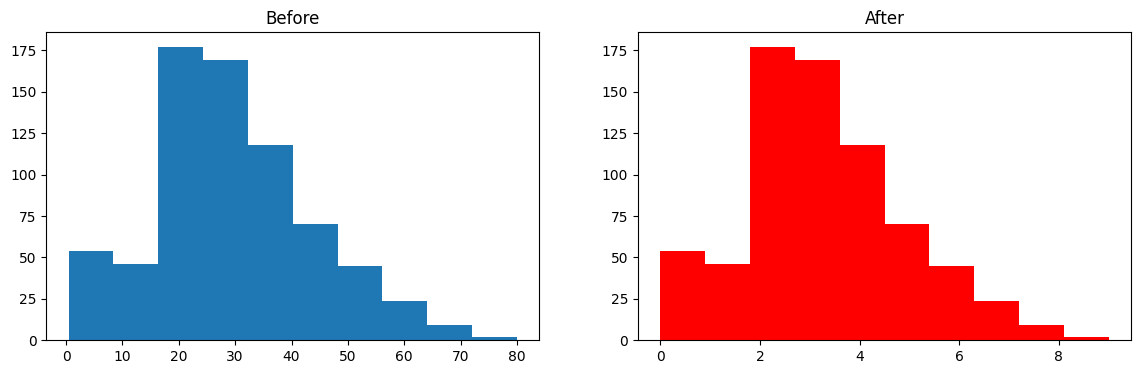

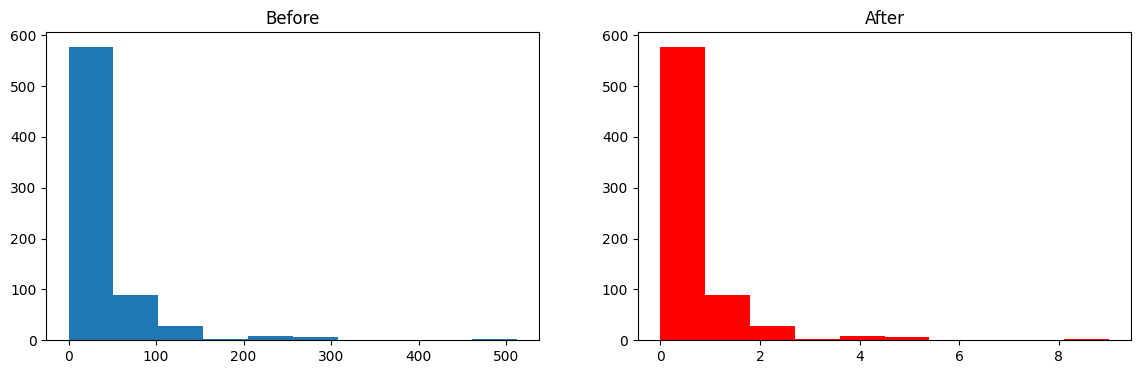

In [35]:
discretize(10, 'uniform')

0.6302425665101721


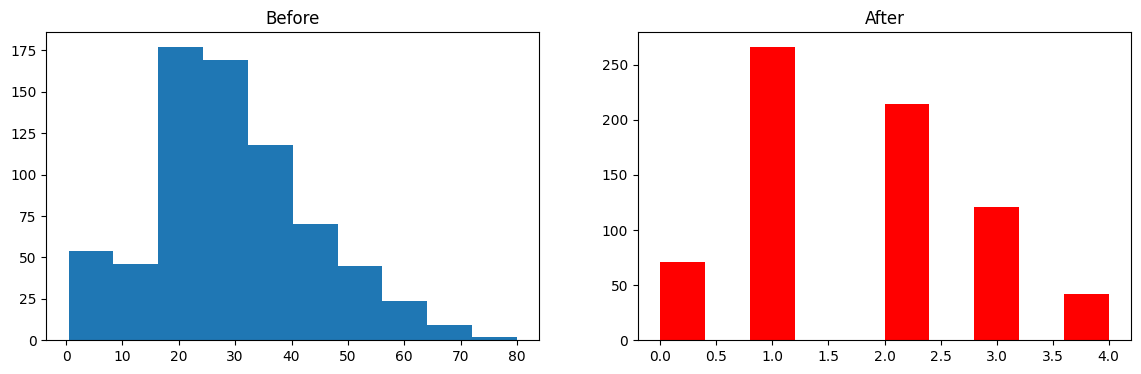

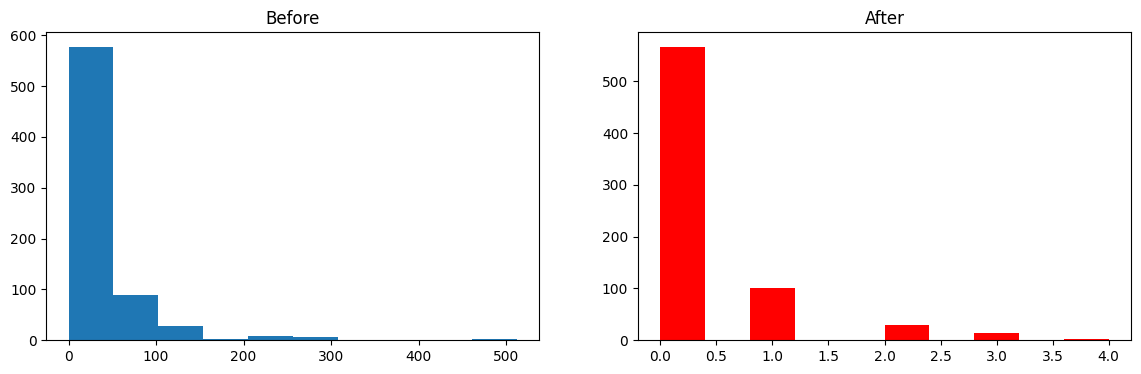

In [36]:
discretize(5, 'kmeans')

In [40]:
newdf=pd.read_csv("train.csv")[['Age', 'Fare', 'SibSp', 'Parch', 'Survived']]

In [41]:
newdf.dropna(inplace=True)

In [42]:
newdf.head()

,Age,Fare,SibSp,Parch,Survived
0,22.0,7.2500,1,0,0
1,38.0,71.2833,1,0,1
2,26.0,7.9250,0,0,1
3,35.0,53.1000,1,0,1
4,35.0,8.0500,0,0,0


In [43]:
newdf['Family']=newdf['SibSp']+newdf['Parch']

In [44]:
newdf.head()

,Age,Fare,SibSp,Parch,Survived,Family
0,22.0,7.2500,1,0,0,1
1,38.0,71.2833,1,0,1,1
2,26.0,7.9250,0,0,1,0
3,35.0,53.1000,1,0,1,1
4,35.0,8.0500,0,0,0,0


In [46]:
newdf.drop(columns=['SibSp', 'Parch'], inplace=True)

In [47]:
newdf.head()

,Age,Fare,Survived,Family
0,22.0,7.2500,0,1
1,38.0,71.2833,1,1
2,26.0,7.9250,1,0
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [49]:
X=newdf.drop(columns=['Survived'])
Y=newdf['Survived']

In [50]:
X_train, X_test, Y_train, Y_test=train_test_split(X, Y, test_size=0.2, random_state=42)

In [51]:
X_train.head()

,Age,Fare,Family
328,31.0,20.5250,2
73,26.0,14.4542,1
253,30.0,16.1000,1
719,33.0,7.7750,0
666,25.0,13.0000,0


In [52]:
# without binarization
clf=DecisionTreeClassifier()
clf.fit(X_train, Y_train)
Y_pred=clf.predict(X_test)
accuracy_score(Y_test, Y_pred)

0.6293706293706294

In [53]:
np.mean(cross_val_score(DecisionTreeClassifier(), X, Y, cv=10, scoring='accuracy'))

np.float64(0.6471439749608764)

In [54]:
# with applying binarization
from sklearn.preprocessing import Binarizer

In [55]:
trf=ColumnTransformer([
    ('bin', Binarizer(copy=False), ['Family'])
], remainder='passthrough')

In [56]:
X_train_trf=trf.fit_transform(X_train)
X_test_trf=trf.transform(X_test)
#

In [57]:
pd.DataFrame(X_train_trf, columns=['Family', 'Age', 'Fare'])
#

,Family,Age,Fare
0,1.0,31.0,20.5250
1,1.0,26.0,14.4542
2,1.0,30.0,16.1000
3,0.0,33.0,7.7750
4,0.0,25.0,13.0000
...,...,...,...
566,1.0,46.0,61.1750
567,0.0,25.0,13.0000
568,0.0,41.0,134.5000
569,1.0,33.0,20.5250


In [58]:
clf=DecisionTreeClassifier()
clf.fit(X_train_trf, Y_train)
Y_pred2=clf.predict(X_test_trf)
accuracy_score(Y_test, Y_pred2)
#

0.5804195804195804

In [59]:
X_trf=trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(), X_trf, Y, cv=10, scoring='accuracy'))
#

np.float64(0.6233763693270735)